## The dataset represent house/property sales in King County, USA (area around seatlle) between May 2014 and May 2015.

In [3]:
# Sync dependencies (Ensures google-cloud-bigquery is present)
%pip install -r ../requirements.txt

In [4]:
import os
import sys

# Add project root to path so we can import from 'src'
sys.path.append(os.path.abspath(".."))
from src.cloud.bigquery_io import query_to_dataframe 
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

# Configuration
PROJECT_ID = "valore-mlsd-project"
DATASET_ID = "valore"
TABLE_NAME = "housing_raw"
TABLE = f"`{PROJECT_ID}.{DATASET_ID}.{TABLE_NAME}`"

# The Query
query = f"SELECT * FROM {TABLE}"

# Create the DataFrame
df = query_to_dataframe(query)


### A. Overall dataset analysis

In [5]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  Int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  Int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  Int64  
 6   sqft_lot       21613 non-null  Int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  Int64  
 9   view           21613 non-null  Int64  
 10  condition      21613 non-null  Int64  
 11  grade          21613 non-null  Int64  
 12  sqft_above     21613 non-null  Int64  
 13  sqft_basement  21613 non-null  Int64  
 14  yr_built       21613 non-null  Int64  
 15  yr_renovated   21613 non-null  Int64  
 16  zipcode        21613 non-null  Int64  
 17  lat            21613 non-null  float64
 18  long  

It contains 21 features and 21613 rows. We see that they are no null values in our dataset. The target variable is the price of the property. The id feature won't be necessary and can be dropped. The **date** type object should be change to be able to be fit in the subsequent analysis. For easier interpretability as european, we will change each occurence of sqft (square_foot) to sqm (squared_meter).

In [6]:
# Remove id 
df = df.drop("id", axis=1)

# date type modification into a proper date format
df["date"] = pd.to_datetime(df["date"])

# modification of sqft to sqm
SQFT_TO_SQM = 0.092903
sqft_cols = df.filter(like='sqft').columns
df[sqft_cols] = df[sqft_cols] * SQFT_TO_SQM
df.rename(columns=lambda c: c.replace('sqft', 'sqm'), inplace=True)
df.head()

,date,price,bedrooms,bathrooms,sqm_living,sqm_lot,floors,waterfront,view,condition,grade,sqm_above,sqm_basement,yr_built,yr_renovated,zipcode,lat,long,sqm_living15,sqm_lot15
0,2014-09-26,142000.0,0,0.00,26.94187,1939.350125,1.0,0,0,1,1,26.94187,0.0,1963,0,98024,47.5308,-121.888,150.50286,2122.83355
1,2015-02-25,262000.0,1,0.75,48.30956,1205.973843,1.0,0,0,5,3,48.30956,0.0,1920,0,98022,47.2082,-121.995,124.49002,1136.482399
2,2015-02-17,75000.0,1,0.00,62.24501,4029.853431,1.0,0,0,3,3,62.24501,0.0,1966,0,98022,47.2638,-121.906,107.76748,3983.866446
3,2014-11-04,280000.0,1,0.00,55.7418,2276.216403,1.0,0,0,2,3,55.7418,0.0,1950,0,98045,47.5316,-121.749,91.97397,2094.869747
4,2014-08-25,145000.0,1,0.75,44.59344,905.80425,1.0,0,0,2,4,44.59344,0.0,1948,0,98146,47.4982,-122.362,143.99965,921.969372


In [7]:
# Count total identical rows
duplicate_count = df.duplicated().sum()
print(f"Total exact duplicate rows: {duplicate_count}")

Total exact duplicate rows: 0


### B. Feature analysis

Let's analyse the main statistical metrics associated to each feature :

#### 1. date

In [8]:
df[["date"]].describe()

,date
count,21613
mean,2014-10-29 04:38:01.959931392
min,2014-05-02 00:00:00
25%,2014-07-22 00:00:00
50%,2014-10-16 00:00:00
75%,2015-02-17 00:00:00
max,2015-05-27 00:00:00


This correspond to what is expected with the dataset description and there does not seems to be any error. 

#### 2. price

In [9]:
df[["price"]].describe()

,price
count,2.161300e+04
mean,5.400886e+05
std,3.671268e+05
min,7.500000e+04
25%,3.219500e+05
50%,4.500000e+05
75%,6.450000e+05
max,7.700000e+06


There is a huge price range between the min (78k) and the max (7.7 million), with a median of 450k, indicating that there are huge outliers and the distribution is right-skewed. It may interesting to see if these really high prices are data error or justified high value properties.

,date,price,bedrooms,bathrooms,sqm_living,sqm_lot,floors,waterfront,view,condition,grade,sqm_above,sqm_basement,yr_built,yr_renovated,zipcode,lat,long,sqm_living15,sqm_lot15
21508,2014-06-11,7062500.0,5,4.50,932.74612,3467.604475,2.0,1,2,3,11,713.49504,219.25108,1940,2001,98004,47.6500,-122.214,365.10879,2364.288447
21609,2014-10-13,7700000.0,6,8.00,1119.48115,2564.1228,2.5,0,3,4,13,796.17871,323.30244,1910,1987,98102,47.6298,-122.323,366.03782,817.5464
21611,2014-09-19,6885000.0,6,7.75,918.81067,2914.738722,2.0,0,4,3,13,823.12058,95.69009,2001,0,98039,47.6305,-122.240,421.77962,3969.74519


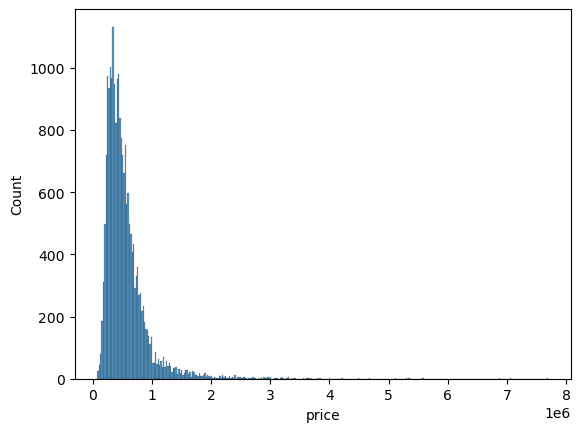

In [10]:
import seaborn as sns
sns.histplot(data=df, x="price")

# Cut-off chosen based on the distribution below. 
display(df[df["price"] >= 6e6])

The plot above confirm our idea of a right skewed distribution. Depending on which ml technique will be chosen, the log(price) may be for appropriate as a target variable, for instance when using linear regression. Moreover, nothing really suspicious can be note about these high valued properties as they are associated with high number of bedrooms, bathrooms, living_size, lot_size, ...  

#### 3. bedrooms

In [11]:
df[["bedrooms"]].describe()

,bedrooms
count,21613.0
mean,3.370795
std,0.930105
min,0.0
25%,3.0
50%,3.0
75%,4.0
max,33.0


A typical property has 3-4 bedrooms. Some have as low as 0 which could indicate loft or studio appartment where there is not a separate bedroom or as high as 33 which is unlikely and therefore must be associated with a very big property or is a data error. 

'Description of properties with more than 10 bedrooms'

,date,price,bedrooms,bathrooms,sqm_living,sqm_lot,floors,waterfront,view,condition,grade,sqm_above,sqm_basement,yr_built,yr_renovated,zipcode,lat,long,sqm_living15,sqm_lot15
4111,2014-08-21,520000.0,11,3.00,278.709,460.79888,2.0,0,0,3,7,222.9672,55.7418,1918,1999,98106,47.5560,-122.363,131.92226,460.79888
4898,2014-06-25,640000.0,33,1.75,150.50286,557.418,1.0,0,0,5,7,96.61912,53.88374,1947,0,98103,47.6878,-122.331,123.56099,436.6441
7974,2014-10-29,650000.0,10,2.00,335.37983,1106.846342,2.0,0,0,4,7,279.63803,55.7418,1958,0,98006,47.5705,-122.175,189.52212,1106.846342
10423,2014-12-29,660000.0,10,3.00,271.27676,347.921735,2.0,0,0,4,7,172.79958,98.47718,1913,0,98105,47.6635,-122.320,168.15443,347.921735
17510,2014-08-14,1148000.0,10,5.25,426.42477,1014.50076,1.0,0,2,3,9,232.2575,194.16727,2008,0,98004,47.5861,-122.113,253.62519,966.1912


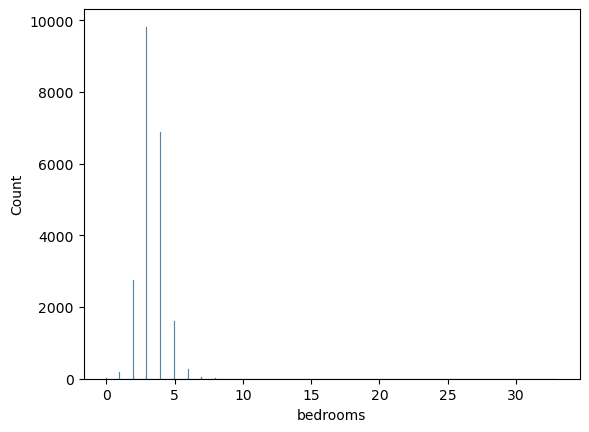

In [12]:
sns.histplot(data=df, x="bedrooms")

# The cutoff of 10 is chosen by looking at the distribution of the number of bedrooms
display("Description of properties with more than 10 bedrooms")
display(df[df["bedrooms"] >= 10])

# Keep all the rows except the one associated with the 33 bedrooms, see explanation belows
df = df[df["bedrooms"] != 33]


It seems that the data point associated with 33 bedrooms is unrealistic as is associated with 150 square meters for all living area, which would mean that each bedroom could at most be around 4.5 square meters while not including that there also must be space for the kitchen, living_room, ... It will therefore be removed. 

#### 4. Bathrooms

In [13]:
df[["bathrooms"]].describe()

,bathrooms
count,21612.000000
mean,2.114774
std,0.770177
min,0.000000
25%,1.750000
50%,2.250000
75%,2.500000
max,8.000000


A typical property has around 2 bathrooms with an outlier of 8 bedrooms and some with 0 bedrooms. The latter is unlikely that they would be no bathroom in residential housing.  Housing property in King country usa not containing a bathroom built after 1960 (and without renovation) seems to unlikely and will also be removed.

In [14]:
display("Description of properties with 0 bathrooms")
display(df[df["bathrooms"] == 0])
# Keep all the rows except the one associated with 0 bathrooms and built after 1960, see explanation belows
df = df[~((df["bathrooms"] == 0) & (df["yr_built"] > 1960))]

'Description of properties with 0 bathrooms'

,date,price,bedrooms,bathrooms,sqm_living,sqm_lot,floors,waterfront,view,condition,grade,sqm_above,sqm_basement,yr_built,yr_renovated,zipcode,lat,long,sqm_living15,sqm_lot15
0,2014-09-26,142000.0,0,0.0,26.94187,1939.350125,1.0,0,0,1,1,26.94187,0.0,1963,0,98024,47.5308,-121.888,150.50286,2122.83355
2,2015-02-17,75000.0,1,0.0,62.24501,4029.853431,1.0,0,0,3,3,62.24501,0.0,1966,0,98022,47.2638,-121.906,107.76748,3983.866446
3,2014-11-04,280000.0,1,0.0,55.7418,2276.216403,1.0,0,0,2,3,55.7418,0.0,1950,0,98045,47.5316,-121.749,91.97397,2094.869747
2471,2014-09-18,484000.0,1,0.0,64.10307,2159.437332,1.0,0,0,4,7,64.10307,0.0,1948,0,98053,47.6429,-121.955,157.00607,1792.09887
8373,2014-06-12,1095000.0,0,0.0,284.654792,442.589892,3.5,0,2,3,7,284.654792,0.0,1990,0,98102,47.6362,-122.322,219.25108,371.612
9609,2014-12-23,235000.0,0,0.0,136.56741,445.9344,2.0,0,0,3,7,136.56741,0.0,1996,0,98065,47.5265,-121.828,98.47718,668.9016
11181,2015-04-13,139950.0,0,0.0,78.410132,396.602907,1.0,0,0,4,7,78.410132,0.0,1913,0,98001,47.2781,-122.250,128.20614,891.8688
13719,2015-04-29,355000.0,0,0.0,228.54138,747.776247,2.0,0,0,3,8,228.54138,0.0,1990,0,98031,47.4095,-122.168,234.11556,747.86915
14205,2015-02-05,380000.0,0,0.0,136.56741,90.952037,3.0,0,2,3,8,136.56741,0.0,2006,0,98133,47.7145,-122.356,136.56741,129.971297
21546,2014-06-24,1295650.0,0,0.0,446.86343,2602.027224,2.0,0,0,3,12,446.86343,0.0,1990,0,98053,47.6642,-122.069,440.36022,3257.272083


'Description of properties with more than 6 bathrooms'

,date,price,bedrooms,bathrooms,sqm_living,sqm_lot,floors,waterfront,view,condition,grade,sqm_above,sqm_basement,yr_built,yr_renovated,zipcode,lat,long,sqm_living15,sqm_lot15
2720,2014-08-11,450000.0,9,7.50,376.25715,604.241112,2.0,0,0,3,7,376.25715,0.0,1996,0,98144,47.5923,-122.301,134.523544,359.162998
21136,2015-03-28,1180000.0,6,6.50,581.57278,1017.752365,2.0,0,0,3,11,449.65052,131.92226,2007,0,98075,47.5947,-122.039,251.76713,1165.93265
21394,2014-07-02,3300000.0,5,6.25,745.08206,2019.525414,2.0,0,0,3,11,745.08206,0.0,2001,0,98006,47.5675,-122.189,386.47648,1762.277007
21494,2014-10-07,800000.0,7,6.75,694.91444,3870.710592,2.0,0,2,3,11,471.94724,222.9672,1953,0,98166,47.4643,-122.368,261.05743,3083.45057
21520,2014-05-05,2280000.0,7,8.00,1257.90662,28591.084056,3.0,0,4,3,12,874.21723,383.68939,1999,0,98053,47.6675,-121.986,450.57955,20234.2734
21531,2014-06-17,4668000.0,5,6.75,895.58492,1214.056404,1.0,1,4,3,12,447.79246,447.79246,1983,2009,98040,47.5570,-122.210,303.79281,971.207962
21541,2014-05-09,2238890.0,5,6.50,675.40481,12078.969351,2.0,0,0,3,12,596.43726,78.96755,2010,0,98027,47.5371,-121.982,167.2254,4170.41567
21603,2014-06-11,2888000.0,5,6.25,805.46901,5948.857799,2.0,0,4,3,13,568.56636,236.90265,1965,2003,98177,47.7295,-122.372,384.61842,7527.093963
21609,2014-10-13,7700000.0,6,8.00,1119.48115,2564.1228,2.5,0,3,4,13,796.17871,323.30244,1910,1987,98102,47.6298,-122.323,366.03782,817.5464
21611,2014-09-19,6885000.0,6,7.75,918.81067,2914.738722,2.0,0,4,3,13,823.12058,95.69009,2001,0,98039,47.6305,-122.240,421.77962,3969.74519


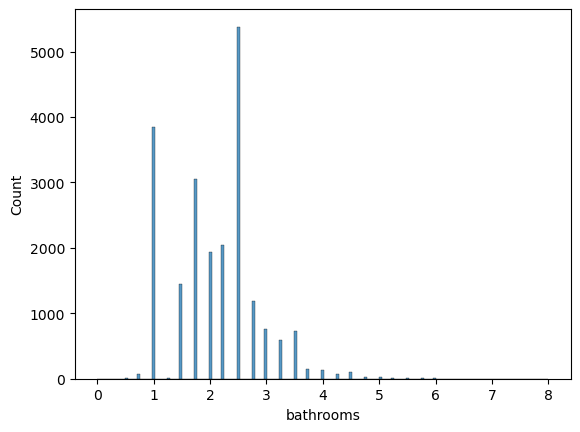

In [15]:
sns.histplot(data=df, x="bathrooms")
# The cutoff of 6 is chosen by looking at the distribution of the number of bathrooms
display("Description of properties with more than 6 bathrooms")
display(df[df["bathrooms"] > 6])


There does not seem to be an error with the property having more than 6 bathrooms as they are associated with a high sqm_living. 

#### 5. sqm_living

,sqm_living
count,21605.0
mean,193.232302
std,85.307266
min,34.37411
25%,132.572581
50%,177.44473
75%,236.90265
max,1257.90662


'Description of properties with more than 800 sqm_living'

,date,price,bedrooms,bathrooms,sqm_living,sqm_lot,floors,waterfront,view,condition,grade,sqm_above,sqm_basement,yr_built,yr_renovated,zipcode,lat,long,sqm_living15,sqm_lot15
21508,2014-06-11,7062500.0,5,4.50,932.74612,3467.604475,2.0,1,2,3,11,713.49504,219.25108,1940,2001,98004,47.6500,-122.214,365.10879,2364.288447
21520,2014-05-05,2280000.0,7,8.00,1257.90662,28591.084056,3.0,0,4,3,12,874.21723,383.68939,1999,0,98053,47.6675,-121.986,450.57955,20234.2734
21531,2014-06-17,4668000.0,5,6.75,895.58492,1214.056404,1.0,1,4,3,12,447.79246,447.79246,1983,2009,98040,47.5570,-122.210,303.79281,971.207962
21603,2014-06-11,2888000.0,5,6.25,805.46901,5948.857799,2.0,0,4,3,13,568.56636,236.90265,1965,2003,98177,47.7295,-122.372,384.61842,7527.093963
21606,2014-08-04,5570000.0,5,5.75,854.7076,3258.015307,2.0,0,0,3,13,575.9986,278.709,2001,0,98039,47.6289,-122.233,330.73468,2261.723535
21609,2014-10-13,7700000.0,6,8.00,1119.48115,2564.1228,2.5,0,3,4,13,796.17871,323.30244,1910,1987,98102,47.6298,-122.323,366.03782,817.5464
21611,2014-09-19,6885000.0,6,7.75,918.81067,2914.738722,2.0,0,4,3,13,823.12058,95.69009,2001,0,98039,47.6305,-122.240,421.77962,3969.74519


,sqm_living,sqm_above,sqm_basement


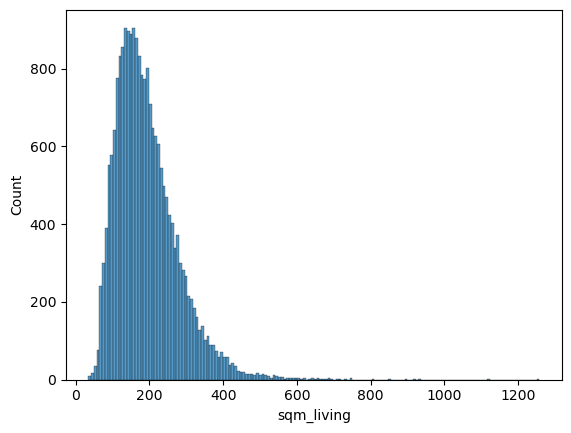

In [16]:
display(df[["sqm_living"]].describe())
sns.histplot(data=df, x="sqm_living")

# The cutoff of 800 is chosen by looking at the distribution below
display("Description of properties with more than 800 sqm_living")
display(df[df["sqm_living"] > 800])

# There are in this dataset the features sqm_above and sqm_basement, such that
# sqm_living = sqm_above + sqm_basement. We will check this consistency. 
# avoids false mismatches due to tiny numerical differences.
df.loc[
    ~np.isclose(
        df["sqm_living"],
        df["sqm_above"] + df["sqm_basement"]
    ),
    ["sqm_living", "sqm_above", "sqm_basement"]
]

There is a more or less a gaussian distribution around 200 sqm, a bit right skewed towards big outlying values, which me be plausible for luxury property. There seems to be no data error when looking at property with sqm > 800 and the min of 34 sqm is plausible for a flat for instance. Moreover, all properties are consistent with the property sqm_living = sqm_above + sqm_basement.

#### 6. sqm_lot

,sqm_lot
count,21605.0
mean,1403.499824
std,3848.722034
min,48.30956
25%,468.23112
50%,707.735054
75%,992.854361
max,153416.205177


'Description of properties with more than 40000 sqm_lot'

,date,price,bedrooms,bathrooms,sqm_living,sqm_lot,floors,waterfront,view,condition,grade,sqm_above,sqm_basement,yr_built,yr_renovated,zipcode,lat,long,sqm_living15,sqm_lot15
89,2014-09-04,375000.0,1,1.00,74.3224,49573.96983,1.5,0,0,5,5,74.3224,0.0,1950,0,98038,47.4134,-121.986,166.29637,20072.343471
161,2015-05-04,190000.0,2,1.00,65.96113,108212.856982,1.0,0,0,2,5,65.96113,0.0,1915,0,98014,47.6888,-121.909,156.07704,1554.26719
487,2015-03-27,700000.0,4,1.00,120.7739,153416.205177,1.0,0,3,4,6,120.7739,0.0,1920,0,98022,47.2313,-122.023,237.83168,39537.751643
3066,2014-08-19,428000.0,3,1.75,146.78674,47105.351314,1.0,0,2,4,7,146.78674,0.0,1985,0,98022,47.2303,-121.936,189.52212,19546.233782
3067,2014-12-22,525000.0,3,2.25,189.52212,40468.5468,2.0,0,2,4,7,189.52212,0.0,1983,0,98022,47.2328,-121.945,187.66406,20719.877381
4725,2015-02-23,425000.0,3,2.75,126.34808,50383.340766,1.0,0,2,4,7,105.90942,20.43866,1955,0,98022,47.2069,-122.024,157.9351,5625.090844
5088,2014-09-29,550000.0,3,2.00,339.09595,78345.936027,2.0,0,0,4,7,339.09595,0.0,1991,0,98070,47.3627,-122.496,173.72861,25454.678776
5488,2014-08-14,800000.0,5,1.75,179.30279,46579.334528,2.0,0,0,3,7,179.30279,0.0,1930,0,98014,47.6294,-121.911,158.86413,8093.70936
6209,2014-12-03,350000.0,4,2.25,145.85771,46411.644613,1.0,0,3,4,7,145.85771,0.0,1972,0,98022,47.1808,-122.023,157.9351,16881.218324
6428,2014-05-08,330000.0,2,2.00,143.99965,40468.5468,1.5,0,0,2,7,143.99965,0.0,1972,0,98065,47.5145,-121.853,148.6448,20234.2734


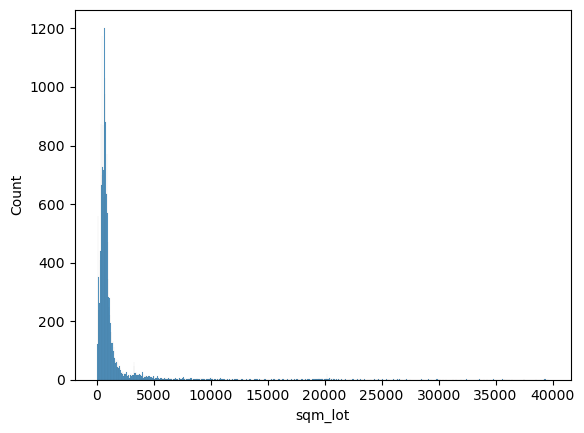

In [17]:
display(df[["sqm_lot"]].describe())
sns.histplot(
    data=df[df["sqm_lot"] <= 40000],
    x="sqm_lot"
)
display("Description of properties with more than 40000 sqm_lot")
display(df[df["sqm_lot"] > 40000])

The distribution is right skewed with some huge outlier (>40000) but we can't really conclude if it is a error, it may be farmland for instance.  

#### 7. floors

,floors
count,21605.000000
mean,1.494145
std,0.539755
min,1.000000
25%,1.000000
50%,1.500000
75%,2.000000
max,3.500000


<Axes: xlabel='floors', ylabel='Count'>

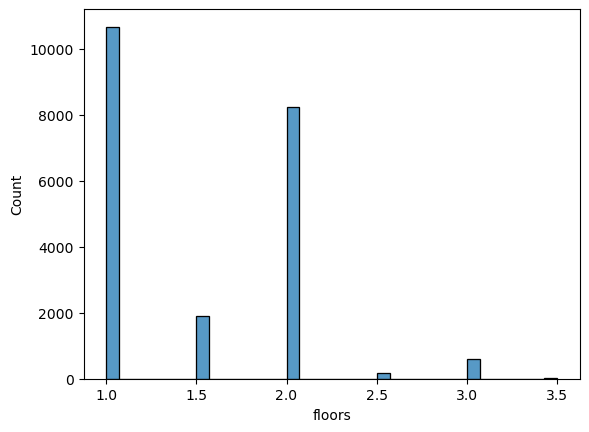

In [18]:
display(df[["floors"]].describe())
sns.histplot(data=df, x="floors")

There does not seem to be any data error associated with this metric. 

#### 8. Waterfront

,waterfront
count,21605.0
mean,0.007545
std,0.086533
min,0.0
25%,0.0
50%,0.0
75%,0.0
max,1.0


'Description of properties with waterfront view'

,date,price,bedrooms,bathrooms,sqm_living,sqm_lot,floors,waterfront,view,condition,grade,sqm_above,sqm_basement,yr_built,yr_renovated,zipcode,lat,long,sqm_living15,sqm_lot15
122,2014-10-27,369900.0,1,0.75,70.60628,936.369337,1.0,1,4,5,5,70.60628,0.0,1936,0,98070,47.4683,-122.438,114.27069,1325.447101
146,2014-11-17,285000.0,1,1.00,98.47718,5095.357938,1.0,1,4,3,5,98.47718,0.0,1935,0,98070,47.4716,-122.445,209.774974,2950.785086
173,2014-10-09,290000.0,2,0.75,40.87732,772.302639,1.0,1,3,4,5,40.87732,0.0,1943,0,98070,47.4339,-122.512,81.75464,2442.326967
252,2015-01-14,658000.0,2,1.00,93.83203,1323.310332,1.0,1,4,1,5,93.83203,0.0,1926,0,98136,47.5476,-122.399,169.08346,1467.124176
325,2014-09-17,340000.0,2,0.75,98.47718,4486.471676,1.0,1,2,5,6,52.02568,46.4515,1947,0,98070,47.4285,-122.511,69.67725,7450.913503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21531,2014-06-17,4668000.0,5,6.75,895.58492,1214.056404,1.0,1,4,3,12,447.79246,447.79246,1983,2009,98040,47.5570,-122.210,303.79281,971.207962
21551,2014-08-19,2300000.0,4,3.25,381.83133,1479.851887,2.0,1,4,3,12,252.69616,129.13517,2001,0,98115,47.6934,-122.271,245.26392,1479.851887
21582,2014-12-01,1637500.0,3,3.50,432.92798,1966.199092,2.0,1,4,3,12,432.92798,0.0,1975,1990,98166,47.4418,-122.354,291.71542,2255.127422
21588,2015-04-13,5300000.0,6,6.00,686.55317,2306.688587,2.0,1,4,4,12,464.515,222.03817,1991,0,98040,47.5631,-122.210,401.34096,2287.178957


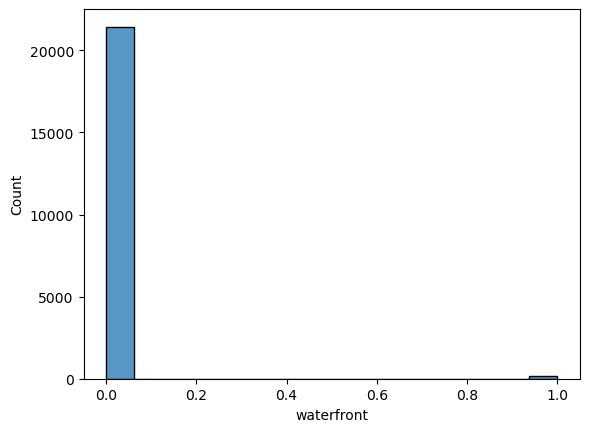

In [19]:
display(df[["waterfront"]].describe())
sns.histplot(data=df, x="waterfront")
display("Description of properties with waterfront view")
display(df[df["waterfront"] == 1])

This feature indicate if the property has waterfront view (0 for no, 1 for yes). No error can therefore be detected at this stage. Most of the property do not have this watefront view. Except for one property (price = 369900), all the property having this view are in the percentile 75 or more for the property price ( > 645.000).

#### 9. View

,view
count,21605.0
mean,0.234205
std,0.766261
min,0.0
25%,0.0
50%,0.0
75%,0.0
max,4.0


<Axes: xlabel='view', ylabel='Count'>

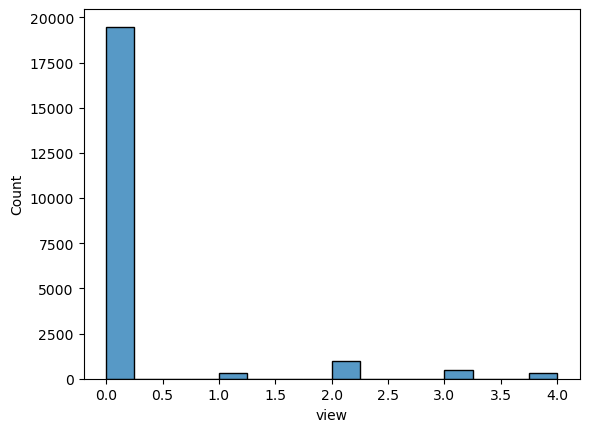

In [20]:
display(df[["view"]].describe())
sns.histplot(data=df, x="view")

This feature indicate the quality level of property view. Most of the property have a value 0 for it. No error can be detected. 

#### 10. Condition

,condition
count,21605.0
mean,3.409581
std,0.650531
min,1.0
25%,3.0
50%,3.0
75%,4.0
max,5.0


<Axes: xlabel='condition', ylabel='Count'>

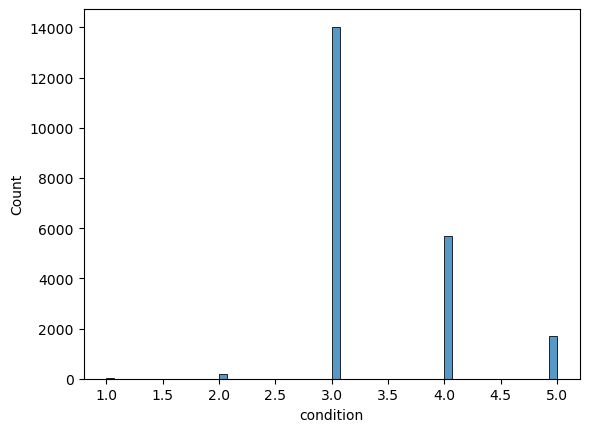

In [21]:
display(df[["condition"]].describe())
sns.histplot(data=df, x="condition")

This indicates the overall condition rating (1 to 5) of the property. Most seemed ok or good with only a really small amount below 3.

#### 11. grade

,grade
count,21605.0
mean,7.657255
std,1.173974
min,3.0
25%,7.0
50%,7.0
75%,8.0
max,13.0


<Axes: xlabel='grade', ylabel='Count'>

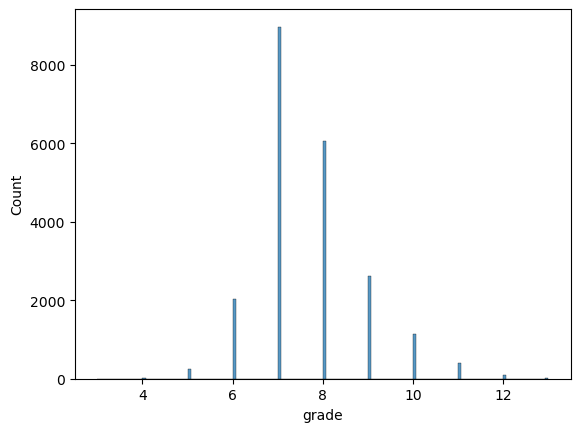

In [22]:
display(df[["grade"]].describe())
sns.histplot(data=df, x="grade")

This feature indicate the averall grade rating (quality of construction and design) ,1 to 13. It has a shape similar to a gaussian center around the level 7-8.

#### 12. sqm_above

,sqm_above
count,21605.0
mean,166.142703
std,76.906215
min,34.37411
25%,110.55457
50%,144.92868
75%,205.31563
max,874.21723


<Axes: xlabel='sqm_above', ylabel='Count'>

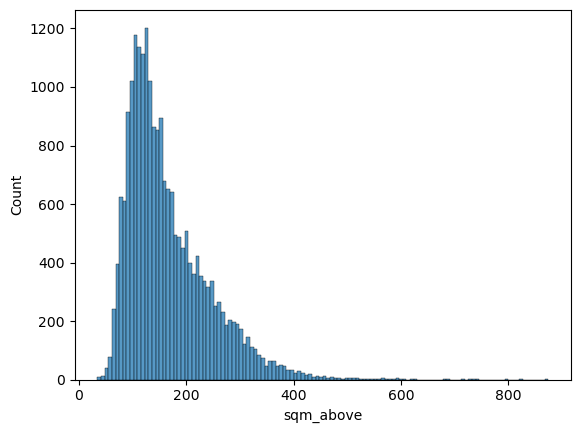

In [23]:
display(df[["sqm_above"]].describe())
sns.histplot(data=df, x="sqm_above")

It shows a right skewed distribution. 

#### 13. sqm_basement

,sqm_basement
count,21605.0
mean,27.089599
std,41.120867
min,0.0
25%,0.0
50%,0.0
75%,52.02568
max,447.79246


<Axes: xlabel='sqm_basement', ylabel='Count'>

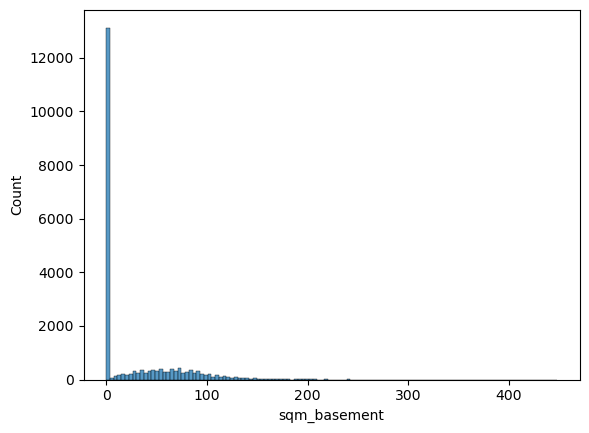

In [24]:
display(df[["sqm_basement"]].describe())
sns.histplot(data=df, x="sqm_basement")

Most of the majority do not have basement. We could expect that the properties with a basement have a higher price. 

#### 14. yr_built

,yr_built
count,21605.0
mean,1971.001435
std,29.376015
min,1900.0
25%,1951.0
50%,1975.0
75%,1997.0
max,2015.0


<Axes: xlabel='yr_built', ylabel='Count'>

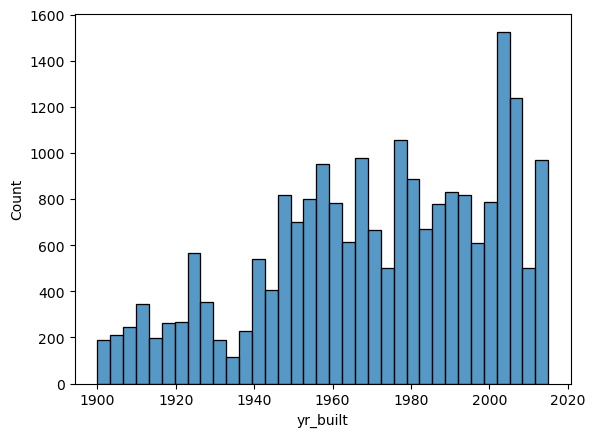

In [25]:
display(df[["yr_built"]].describe())
sns.histplot(data=df, x="yr_built")

Most of the properties (75%) are built after 1950, there does not seem to be data error. 

#### 15. yr_renovated 

Text(0.5, 1.0, 'Only renovated houses')

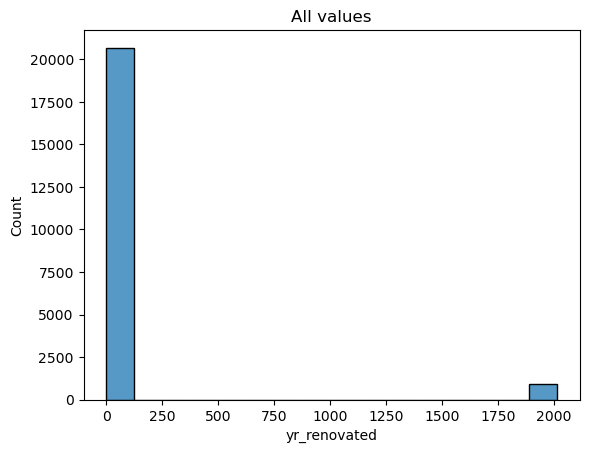

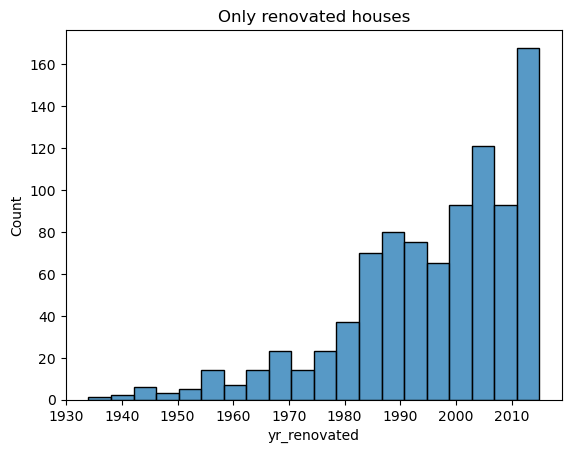

In [26]:
plt.figure()
sns.histplot(data=df, x="yr_renovated")
plt.title("All values")

plt.figure()
sns.histplot(data=df[df["yr_renovated"] > 0], x="yr_renovated")
plt.title("Only renovated houses")

Most of the properties have not been renovated. For those who have, its mainly after 1980.

#### 16, 17, 18. Zip code, latitue, longitude. 

In [27]:
display(df[["zipcode", "lat", "long"]].describe())
df = df.drop(columns=["zipcode"])

,zipcode,lat,long
count,21605.0,21605.000000,21605.000000
mean,98077.943994,47.560055,-122.213935
std,53.509192,0.138561,0.140786
min,98001.0,47.155900,-122.519000
25%,98033.0,47.471000,-122.328000
50%,98065.0,47.571800,-122.231000
75%,98118.0,47.678000,-122.125000
max,98199.0,47.777600,-121.315000


The properties are located in the Seattle area (King county, USA). No error/outlier is present. In the following, only lat and long will be preserved as they are more precise than zip_code and the zip_code can be found once given the lat and long.  

#### 19. sqm_living15
Living area size of 15 nearest properties in square meters

,sqm_living15
count,21605.0
mean,184.555106
std,63.654133
min,37.068297
25%,138.42547
50%,170.94152
75%,219.25108
max,576.92763


<Axes: xlabel='sqm_living15', ylabel='Count'>

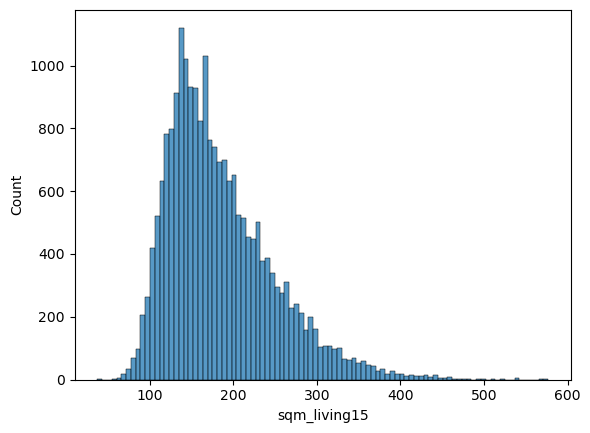

In [28]:
display(df[["sqm_living15"]].describe())
sns.histplot(data=df, x="sqm_living15")

The distribution is right-skewed without abnormous values. 

#### 20. sqm_lot15

Lot size of 15 nearest properties in square feet

,sqm_lot15
count,21605.0
mean,1186.124658
std,2536.965735
min,60.479853
25%,473.8053
50%,707.92086
75%,936.740949
max,80937.0936


'Description of properties with more than 40000 sqm_lot15'

,date,price,bedrooms,bathrooms,sqm_living,sqm_lot,floors,waterfront,view,condition,grade,sqm_above,sqm_basement,yr_built,yr_renovated,lat,long,sqm_living15,sqm_lot15
126,2014-12-12,180000.0,2,1.00,89.18688,8174.627873,1.5,0,0,3,5,89.18688,0.0,1946,0,47.6300,-121.900,180.23182,36421.69212
398,2015-03-23,370000.0,2,1.00,219.25108,9833.78255,1.0,0,2,2,6,109.62554,109.62554,1947,0,47.2495,-121.970,245.26392,35935.995236
487,2015-03-27,700000.0,4,1.00,120.7739,153416.205177,1.0,0,3,4,6,120.7739,0.0,1920,0,47.2313,-122.023,237.83168,39537.751643
3663,2014-07-11,319000.0,3,1.75,152.36092,4961.0202,1.0,0,0,4,7,152.36092,0.0,1966,0,47.3944,-122.506,171.87055,35329.059937
13549,2014-10-19,549950.0,3,1.75,272.20579,24766.732061,2.0,0,0,3,8,226.68332,45.52247,1995,0,47.6991,-121.947,250.8381,40711.302339
17834,2014-08-26,637000.0,4,3.50,286.14124,11047.838954,2.0,0,0,3,9,286.14124,0.0,2008,0,47.7721,-121.924,170.01249,40387.535384
18212,2014-05-09,800000.0,4,3.25,328.87662,14811.52529,2.0,0,0,3,9,328.87662,0.0,2007,0,47.6285,-121.899,180.23182,36421.69212
20109,2014-10-01,858000.0,4,3.50,405.98611,39294.903201,1.0,0,2,4,10,239.68974,166.29637,1978,0,47.2332,-122.029,302.86378,39294.903201
20493,2014-11-07,790000.0,3,2.50,245.26392,40137.440508,1.5,0,3,3,10,245.26392,0.0,1996,0,47.1795,-122.036,139.3545,52083.001151
21126,2015-01-07,937500.0,4,4.00,515.147135,80937.0936,2.0,0,0,3,11,334.915315,180.23182,2003,0,47.6760,-121.882,317.72826,80937.0936


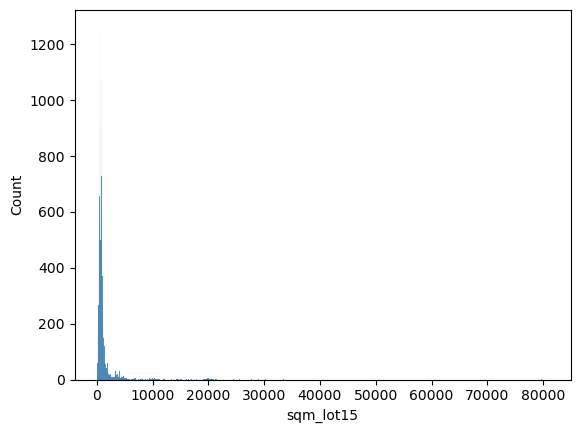

In [29]:
display(df[["sqm_lot15"]].describe())
sns.histplot(data=df, x="sqm_lot15")

display("Description of properties with more than 40000 sqm_lot15")
display(df[df["sqm_lot15"] > 35000])

There seem to be some extreme outlier having more than 35.000 for this metric. By looking closely, it can be explain as these properties already themselves have a high lot area but also are close to the one big outlier 153416 m² which inflate the mean and the metric. No data error is considered. 

### C. Correlation with the target

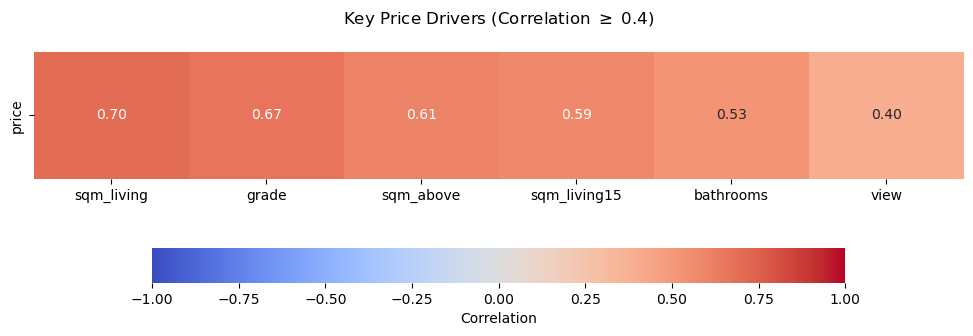

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Calculate correlation
corr_matrix = df.select_dtypes(include=[np.number]).corr()

# 2. Extract and filter (Added the .T at the end of the filter)
target_corr = corr_matrix[['price']]
filtered_target_corr = target_corr[(abs(target_corr['price']) >= 0.39) & (abs(target_corr['price']) < 0.99)]

# 3. Sort and Transpose
# We sort BEFORE transposing so the bars go from highest to lowest left-to-right
filtered_target_corr = filtered_target_corr.sort_values(by='price', ascending=False).T

# 4. Plotting
plt.figure(figsize=(12, 3)) # Wide and short for the horizontal 'strip'
sns.heatmap(
    filtered_target_corr, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f", 
    center=0,
    vmin=-1, 
    vmax=1,
    cbar_kws={'label': 'Correlation', 'orientation': 'horizontal', 'pad': 0.3}
)

plt.title("Key Price Drivers (Correlation $\geq$ 0.4)", pad=20)
plt.savefig("target_correlation_horizontal.png", dpi=300, bbox_inches='tight')
plt.show()

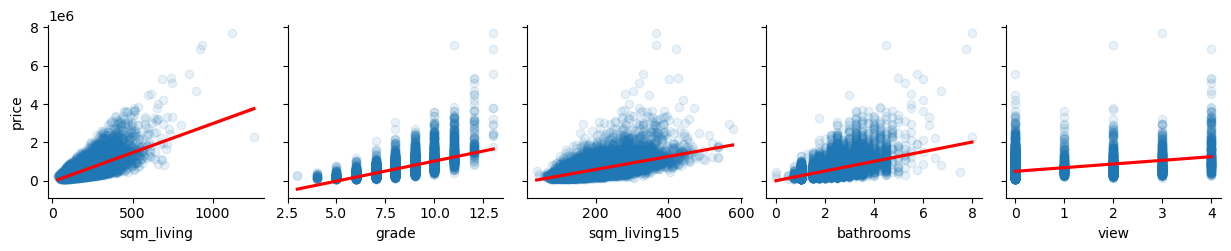

In [31]:
# Choose the 'Top Drivers' based on your correlation analysis
features_to_plot = ['sqm_living', 'grade', 'sqm_living15', 'bathrooms', 'view']
import seaborn as sns
sns.pairplot(
    df, 
    x_vars=features_to_plot, # Features on the X-axis
    y_vars=['price'],        # Only the Target on the Y-axis
    kind='reg',              # Adds a regression line to show the trend
    plot_kws={'line_kws':{'color':'red'}, 'scatter_kws': {'alpha': 0.1}}
)

plt.savefig("target_only_pairplot.png", dpi=300, bbox_inches='tight')
plt.show()

### D. Assessing multicolinearity 

Multicollinearity happens when two or more predictor variables are highly correlated with each other in a dataset. Even though multicollinearity does not significantly harm prediction accuracy for every ml models it is still important to inspect because it improves : model interpretability, deployment simplicity and
monitoring stability.

#### Correlation matrix

In [32]:
plt.figure(figsize=(12,10))
X = numeric_df.drop(columns=['price'])

sns.heatmap(
    X.corr(),
    cmap="coolwarm",
    center=0,
    annot=True,          # shows numbers
    fmt=".2f",           # 2 decimal places
    square=True,
    linewidths=0.5
)

plt.title("Correlation Matrix with Values")
plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

NameError: name 'numeric_df' is not defined

<Figure size 1200x1000 with 0 Axes>

Features with correlation coefficients close to ±1 contain very similar information and may introduce redundancy in the model. We can notice that sqm_above and sqm_living are the most correlated (0.88), there are also some greater than 0.75 but we won't analyse them in details at this stage.

#### Variance Inflation Factor (VIF)

VIF > 10 indicate strong multicolinearity and should be delt with. 

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Prepare X for VIF: Select numbers, cast to standard float64
# This fixes the "ufunc isfinite" error caused by Nullable Int64/Float64
X_vif = X.select_dtypes(include=[np.number]).astype(float)

# 3. Compute VIF
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i) 
    for i in range(X_vif.shape[1])
]

# 4. Sort results
vif_data = vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True)
vif_data

c:\Users\antoi\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Feature,VIF
0,sqm_living,inf
1,sqm_basement,inf
2,sqm_above,inf
3,long,1.332028e+05
4,lat,1.198517e+05
5,yr_built,8.531014e+03
6,grade,1.426895e+02
7,condition,3.468864e+01
8,bathrooms,2.884214e+01
9,sqm_living15,2.679993e+01


- for sqm_above, sqm_living and sqm_basement, it can be expected because of the relation 
sqm_living = sqm_above + sqm_basement . We decided to only keep sqm_living as its the main driver in this relationship but keep the basement aspect by introducing a new variable : basement_ratio = dfsqm_basement / sqm_living. 

In [ ]:
X["basement_ratio"] = X["sqm_basement"] / X["sqm_living"]
X = X.drop(columns=["sqm_basement"])
X = X.drop(columns=["sqm_above"])

df["basement_ratio"] = X["basement_ratio"]
df = df.drop(columns=["sqm_basement"])
df = df.drop(columns=["sqm_above"])

# 1. Select only numeric columns and cast them to standard float64
# This converts 'Int64' and 'Float64' to 'float64', which statsmodels understands
X_vif = X.select_dtypes(include=[np.number]).astype(float)

# 2. Handle missing or infinite values (VIF cannot process these)
# We replace infinite values with NaN and then drop any rows with NaNs
X_vif = X_vif.replace([np.inf, -np.inf], np.nan).dropna()

# 3. Compute VIF
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i) 
    for i in range(X_vif.shape[1])
]

# 4. Sort and display
vif_data = vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True)
vif_data

,Feature,VIF
0,long,133231.633747
1,lat,119908.793799
2,yr_built,8523.401490
3,grade,142.001156
4,condition,34.661377
5,sqm_living,32.705873
6,bathrooms,29.032299
7,sqm_living15,26.441409
8,bedrooms,25.262324
9,floors,16.669218


There is still high VIF values : 

- construction year correlates with condition & grade

- house size sqm_living, bathromms, bedrooms, floor correlate with one another

However, feature removal is stopped here after eliminating strictly redundant variables because the remaining correlations reflect inherent relationships within real-estate data rather than modeling issues.